In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
import sys
import os
# from DeepMods import *
# from STFdataProcess import *

class PredictionModel(nn.Module):
    def __init__(self,numDevices):
        super(PredictionModel,self).__init__()
        self.fc0 = nn.Linear(numDevices,numDevices) # input: [64, 10, 1, 214]
        self.lstm = nn.LSTM(input_size=numDevices, hidden_size=numDevices, 
                            num_layers=1, bidirectional=False,batch_first=False,dropout=0)
        self.fc1 = nn.Linear(numDevices,numDevices*10)
        self.ct1 = nn.Conv2d(1,64,kernel_size=(3,1))
        self.ct2 = nn.Conv2d(64,64,kernel_size=(3,1))
        self.ct3 = nn.Conv2d(64,64,kernel_size=(3,1))
        self.ct4 = nn.Conv2d(64,10,kernel_size=(4,1))
        self.cf1 = nn.Conv2d(10,10,kernel_size=(2,1))
    def forward(self,ds0):    
        dsT = ds0.permute(0,2,1,3) # ds0[bs,T,1,N]--[bs,1,T,N]
        dsT = self.ct1(dsT)
        dsT = self.ct2(F.relu(dsT))
        dsT = self.ct3(F.relu(dsT))
        dsT = self.ct4(F.relu(dsT))
        out = self.fc0(ds0)
        out = out.permute(0,3,2,1) # bs,T,1,N -- bs,N,1,T
        out = out.squeeze(2) # bs,N,T
        out = out.permute(2,0,1) # T,bs,N
        out1, (hn, cn) = self.lstm(F.relu(out)) # hn_[1, bs, N]
        out = hn.unsqueeze(1) # 1,1,bs,N
        out = out.permute(2,0,1,3) # 64,1,1,N
        out = self.fc1(out.squeeze(1).squeeze(1)).reshape(len(out),10,1,-1)
        out = torch.cat((out,dsT),2)
        out = self.cf1(F.relu(out))
        return out   

''' LOAD Data '''
volSpeed = 'vol'
df_DT = pd.read_csv('6minFill5793-2022MayNov-%s_lane.csv'%(volSpeed),parse_dates =['Time'])# ---------------------DATA
df_DT['Time'] = pd.to_datetime(df_DT['Time'])
SETlaneIDs = [i for i in df_DT.columns if i!='Time']
SETlaneIDs = list(np.sort(SETlaneIDs)) # SORT
print('df_DT: {}, SETlaneIDs: {}'.format(df_DT.shape,len(SETlaneIDs)))

''' For Min-Max '''
if volSpeed == 'vol':
    minV = 0.0
    maxV = 824.0 
elif volSpeed == 'Speed':
    minV = 0.0
    maxV = 294.5882352941176
    
'''Min-Max (For Model Inputs)'''
val_df = df_DT[~(df_DT['Time']<pd.to_datetime('2022-11-01'))] # valStartTime -[TestData-2022-12-01]
# val_df = df_DT.copy()

valData = val_df.loc[:,SETlaneIDs].values
valData = (valData-minV)/(maxV-minV)
print('valData: {}, {} -- {}'.format(valData.shape,np.min(valData),np.max(valData)))

''' Median Data -- (Mon, Tues, ..., Sat, Sun, Public Holiday) '''
medData = np.load('Med-6min5793-2022MayNov-%s_lane.npy'%(volSpeed))# ---------------------DATA
medData = (medData-minV)/(maxV-minV) # Min-Max
print('medData: {}, {} -- {}'.format(medData.shape,np.min(medData),np.max(medData)))

''' GET Public Holiday, Median of every 6 min of [Mon, Tues, ..., Sat, Sun, Public Holiday]'''
holData = pd.read_csv('HolInfo-2022MayNov.csv') # ---------------------DATA
holData['Date'] = pd.to_datetime(holData['Date'])
holData = holData[holData['Date'].isin(val_df['Time'].values)]
print('medData:{}, holData:{}'.format(medData.shape,holData.shape))
len_dayTime = 240
print('valData:{}, num_days: {}'.format(valData.shape,len(valData)/len_dayTime))
holData['AWT'] = holData['DoW']
holData.loc[holData[holData['Hol']==3].index,'AWT'] = [7 for k in range(len(holData[holData['Hol']==3]))]
DayHolMed_index = holData['AWT'].values
DayHolMed_index = np.array([int(i) for i in DayHolMed_index])
print('DayHolMed_index: {}'.format(DayHolMed_index.shape))

''' LOAD CLUSTER INFORMATION '''
cluRes = np.load('Clusters_DetectorIndex.npy',allow_pickle=True)# ---------------------DATA
''' Prediction Models Name '''
predModDir = '%sModels/'%(volSpeed)# ---------------------MOD
fns_predModFn = os.listdir(predModDir) 
fns_predModFn = [i for i in fns_predModFn if i.split('.')[-1]=='pt'] 
print('fns_predModFn: {}'.format(len(fns_predModFn)))

num_his,num_pred= 10,10
tmpVal_hisPred = [[startIndexTi+i for i in range(num_his+num_pred)] for startIndexTi in range(len(valData)-num_his-num_pred+1)]
tmpVal_hisPred = np.array(tmpVal_hisPred)
print('tmpVal_hisPred:{}; num_his:{}, num_pred:{}'.format(tmpVal_hisPred.shape,num_his,num_pred))

PredTarget = valData[tmpVal_hisPred][:,10:]
PredTarget = PredTarget*(maxV-minV)+minV
print('PredTarget: {}'.format(PredTarget.shape))

df_DT: (51360, 1913), SETlaneIDs: 1912
valData: (7200, 1912), 0.0 -- 0.7451456310679612
medData: (8, 240, 1912), 0.0 -- 0.32038834951456313
medData:(8, 240, 1912), holData:(30, 4)
valData:(7200, 1912), num_days: 30.0
DayHolMed_index: (30,)
fns_predModFn: 10
tmpVal_hisPred:(7181, 20); num_his:10, num_pred:10
PredTarget: (7181, 10, 1912)


In [4]:

val_df['Time'] = pd.to_datetime(val_df['Time'])

# Filter for times between 6 PM and 9 PM
df_filtered = val_df[(val_df['Time'].dt.time >= pd.to_datetime('6:00').time()) & 
                 (val_df['Time'].dt.time < pd.to_datetime('22:00').time())]

# Remove every alternate 10 rows
def remove_alternate_tenth_rows(df, interval=10):
    # Determine rows to keep
    mask = ~((df.index // interval) % 2 == 1)
    return df[mask]

val_df_filtered = remove_alternate_tenth_rows(df_filtered)

C:\Users\Nahush\AppData\Local\Temp\ipykernel_10256\3505065034.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df['Time'] = pd.to_datetime(val_df['Time'])


In [5]:

# print(df_filtered.to_string())
print(val_df_filtered['Time'].to_string())

44220   2022-11-01 06:00:00
44221   2022-11-01 06:06:00
44222   2022-11-01 06:12:00
44223   2022-11-01 06:18:00
44224   2022-11-01 06:24:00
44225   2022-11-01 06:30:00
44226   2022-11-01 06:36:00
44227   2022-11-01 06:42:00
44228   2022-11-01 06:48:00
44229   2022-11-01 06:54:00
44240   2022-11-01 08:00:00
44241   2022-11-01 08:06:00
44242   2022-11-01 08:12:00
44243   2022-11-01 08:18:00
44244   2022-11-01 08:24:00
44245   2022-11-01 08:30:00
44246   2022-11-01 08:36:00
44247   2022-11-01 08:42:00
44248   2022-11-01 08:48:00
44249   2022-11-01 08:54:00
44260   2022-11-01 10:00:00
44261   2022-11-01 10:06:00
44262   2022-11-01 10:12:00
44263   2022-11-01 10:18:00
44264   2022-11-01 10:24:00
44265   2022-11-01 10:30:00
44266   2022-11-01 10:36:00
44267   2022-11-01 10:42:00
44268   2022-11-01 10:48:00
44269   2022-11-01 10:54:00
44280   2022-11-01 12:00:00
44281   2022-11-01 12:06:00
44282   2022-11-01 12:12:00
44283   2022-11-01 12:18:00
44284   2022-11-01 12:24:00
44285   2022-11-01 1

In [6]:
tmpVal_hisPred

array([[   0,    1,    2, ...,   17,   18,   19],
       [   1,    2,    3, ...,   18,   19,   20],
       [   2,    3,    4, ...,   19,   20,   21],
       ...,
       [7178, 7179, 7180, ..., 7195, 7196, 7197],
       [7179, 7180, 7181, ..., 7196, 7197, 7198],
       [7180, 7181, 7182, ..., 7197, 7198, 7199]])

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
fillType = 'Dynamic'
for ciIndex in range(len(cluRes)):
    model_path = [i for i in fns_predModFn if i.split('_')[-1]=='%s.pt'%(ciIndex)][0] # GET MODEL
    ci = cluRes[ciIndex] # Get the indices of detectors in the cluster
    cluSize = len(ci)
    print('{} ({}),\t{}'.format(ciIndex,cluSize,model_path))
    val_ci = valData[:,ci].copy() # valData columns correspond to the sorted list of detector IDs
    #val_ci[:,[0,3,12]] = np.nan
    if np.isnan(val_ci).any():
        print('WITH NAN---NEED Fill in')
        med_ci = medData[:,:,ci] #8,240,1912
        med_ci_days = med_ci[DayHolMed_index]
        ''' Calculate the ratio of other working detectors in the current cluster to med, and fill in according to the ratio '''
        f_val_ci = val_ci.copy() # f_val_ci[:n]
        f_val_ci = f_val_ci.reshape(-1,len_dayTime,f_val_ci.shape[-1]) # : (61, 240, 236)
        ''' Fill-In Static /Dynamic'''
        if fillType == 'Static':
            f_val_ci[np.isnan(f_val_ci)] = med_ci_days[np.isnan(f_val_ci)]
        elif fillType == 'Dynamic':
            tmp_fvalci = f_val_ci*(maxV-minV)+minV
            tmp_medcidays = med_ci_days*(maxV-minV)+minV
            tmp_medcidays[tmp_medcidays==0] = 1 # Prevent divisor from being 0
            tmp_fvalci[tmp_medcidays==0] = np.nan # Exclude detectors with med of 0 from ratio calculation
            dynamic_med_ci = np.nanmean((tmp_fvalci/tmp_medcidays),-1) # Ratio of other working detectors in the current cluster to med
            dynamic_med_ci = dynamic_med_ci[:,:,np.newaxis]
            dynamic_med_ci = dynamic_med_ci.repeat(cluSize,2)
            f_val_ci[np.isnan(f_val_ci)] = med_ci_days[np.isnan(f_val_ci)] * dynamic_med_ci[np.isnan(f_val_ci)]
    else:
        f_val_ci = val_ci
    f_val_ci = f_val_ci.reshape(-1,f_val_ci.shape[-1])
    val_ci = f_val_ci[tmpVal_hisPred]
    
    val_ci = torch.FloatTensor(val_ci).unsqueeze(2) # [14621, 20, 1, 332]);
    real_fill = val_ci[:,num_his:]
    input_ci = val_ci[:,:num_his,:]
    val_data = torch.utils.data.TensorDataset(input_ci,real_fill)
    val_iter = torch.utils.data.DataLoader(val_data, 2000, shuffle=False) 
    '''LOAD MODEL '''
    model = PredictionModel(cluSize).to(device)
    checkpoints = torch.load(predModDir+model_path,map_location=torch.device('cpu'))# -------------,map_location=torch.device('cpu')
    model.load_state_dict(checkpoints['model']) 
    tmp=0
    model.eval()
    with torch.no_grad():
        for x,y in val_iter:
            x = x.to(device)
            y_pred = model(x)
            if tmp==0:
                predAll_ci = y_pred
                tmp=100
            else:
                predAll_ci = torch.cat((predAll_ci,y_pred),0)
    # with torch.no_grad():
    #     for x,y in val_iter:
    #         x = x.to(device)
    #         predictions = []

    #         for _ in range(10):
    #             y_pred = model(x)
    #             predictions.append(y_pred)
    #             x = y_pred

    #         y_pred_all = torch.cat(predictions, dim=1)
    #         if tmp==0:
    #             predAll_ci = y_pred_all
    #             tmp=100
    #         else:
    #             predAll_ci = torch.cat((predAll_ci,y_pred_all),0)
    #             print(predAll_ci.shape)

    RePred_ci = predAll_ci.cpu()*(maxV-minV)+minV
    if ciIndex==0:
        RePredAll_fri = torch.FloatTensor(len(RePred_ci),RePred_ci.shape[1],RePred_ci.shape[2],len(SETlaneIDs))
    RePredAll_fri[:,:,:,ci] = RePred_ci
    #print(ciIndex,end=' - ')
print('\nRePredAll_fri: {}'.format(RePredAll_fri.shape)) # [14621, 10, 1, 236]             

0 (332),	FPredMod8j3_MML_64E5_0430_181545oRr_0.pt
1 (449),	FPredMod8j3_MML_64E5_0430_181545oRr_1.pt
2 (236),	FPredMod8j3_MML_64E3_0430_181120oRr_2.pt
3 (86),	FPredMod8j3_MML_64E3_0430_181120oRr_3.pt
4 (354),	FPredMod8j3_MML_64E3_0430_181120oRr_4.pt
5 (29),	FPredMod8j3_MML_64E3_0430_181120oRr_5.pt
6 (102),	FPredMod8j3_MML_64E5_0430_181545oRr_6.pt
7 (86),	FPredMod8j3_MML_64E4_0430_181221oRr_7.pt
8 (222),	FPredMod8j3_MML_64E3_0430_181120oRr_8.pt
9 (16),	FPredMod8j3_MML_64E3_0430_181120oRr_9.pt

RePredAll_fri: torch.Size([7181, 10, 1, 1912])


In [9]:
RePredAll_fri = RePredAll_fri.view(7181, 10, 1912)


In [34]:
padding_before = np.zeros((10, 10, 714))
padding_after = np.zeros((9, 10, 714))

# for i in range(1912):
#     # Extract the slice for the current third dimension value
#     slice_data = Repred[:, :, i]
#     df = pd.DataFrame(slice_data)

start_date = '2022-11-01'
end_date = '2022-12-1'

# Create a date range with 6-minute frequency
date_range = pd.date_range(start=start_date, end=end_date, freq='6min')
date_range = date_range[(date_range.time >= pd.to_datetime('06:00').time()) &
                                 (date_range.time < pd.to_datetime('21:00').time())]

    # df['time'] = date_range[:-1]
    # df['Time'] = pd.to_datetime(df['Time'])

#     df_filtered = df[(df['time'].dt.time >= pd.to_datetime('6:00').time()) & 
#                     (df['time'].dt.time < pd.to_datetime('22:00').time())]

#     # Remove every alternate 10 rows
#     def remove_alternate_tenth_rows(df, interval=10):
#         # Determine rows to keep
#         mask = ~((df.index // interval) % 2 == 1)
#         return df[mask]

#     df_filtered = remove_alternate_tenth_rows(df_filtered)

#     arr = df_filtered.values.flatten()
#     print(len(arr))



In [11]:
RePredAll_fri

tensor([[[ 4.3731, 13.7651,  3.5378,  ...,  2.1923, 22.4508,  8.9680],
         [ 3.9731, 13.1377,  3.3113,  ...,  2.0984, 21.3244,  8.5230],
         [ 3.8081, 12.6020,  3.2743,  ...,  1.9192, 20.4530,  8.2533],
         ...,
         [ 3.6664, 10.8790,  3.1880,  ...,  1.2565, 18.3811,  7.0878],
         [ 3.9136, 10.7737,  3.3653,  ...,  1.2056, 18.0231,  6.9913],
         [ 3.6473, 10.6502,  3.0308,  ...,  1.0787, 18.0881,  6.8956]],

        [[ 3.7363, 12.3873,  2.6566,  ...,  2.3868, 22.5200,  8.7155],
         [ 3.4347, 11.8555,  2.5059,  ...,  2.2716, 21.4987,  8.3110],
         [ 3.3463, 11.4381,  2.5218,  ...,  2.1377, 20.5861,  8.0725],
         ...,
         [ 3.2308, 10.2716,  2.5317,  ...,  1.4162, 18.2927,  7.1745],
         [ 3.4543, 10.3178,  2.7431,  ...,  1.3824, 18.1896,  7.0948],
         [ 3.1634, 10.2820,  2.4455,  ...,  1.3534, 18.1809,  7.0550]],

        [[ 3.5654, 11.6386,  2.6287,  ...,  2.0071, 21.1861,  8.4154],
         [ 3.2989, 11.1176,  2.5236,  ...,  2

In [12]:
PredTarget.shape

(7181, 10, 1912)

In [69]:
detectors = []
df_DT.columns = df_DT.columns.str.replace('/', '')
for i in df_DT.columns:
    detectors.append(i.split('_')[0])

detectors = sorted(set(detectors))
detectors.remove('Time')
df = pd.DataFrame(columns=detectors)
lane_count_df = pd.DataFrame(index=[0], columns=detectors)

for detector in detectors:
    # Select columns corresponding to lanes of current detector
    detector_columns = [col for col in df_DT.columns if col.startswith(detector)]
    summed_values = df_DT[detector_columns].sum(axis=1)
    df[detector] = summed_values
    num_lanes = len(detector_columns)
    lane_count_df[detector] = num_lanes

# Add timestamp column to the new dataframe
df['timestamp'] = df_DT['Time']
lane_count_df

C:\Users\Nahush\AppData\Local\Temp\ipykernel_10256\2530552810.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['timestamp'] = df_DT['Time']


,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTYR10002,TDSTYR10003,TDSTYR20001,TDSTYR20003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
0,3,3,3,2,2,2,2,2,3,3,...,2,2,2,2,2,2,2,2,2,2


In [70]:
lane_counts = np.array(lane_count_df.loc[0,:]) # lane counts for each detector in order

# Initialize array to store concatenated values
pred_arr = np.zeros((RePredAll_fri.shape[0], RePredAll_fri.shape[1], len(lane_counts)))

# Sum values for each detector based on lane counts
start_idx = 0
for i, lane_count in enumerate(lane_counts):
    end_idx = start_idx + lane_count
    pred_arr[:, :, i] = torch.sum(RePredAll_fri[:, :, start_idx:end_idx], dim=-1)
    start_idx = end_idx

target_arr = np.zeros((PredTarget.shape[0], PredTarget.shape[1], len(lane_counts)))

# Sum values for each detector based on lane counts
start_idx = 0
for i, lane_count in enumerate(lane_counts):
    end_idx = start_idx + lane_count
    target_arr[:, :, i] = np.sum(PredTarget[:, :, start_idx:end_idx], axis=-1)
    start_idx = end_idx

print(pred_arr.shape,target_arr.shape)

(7181, 10, 714) (7181, 10, 714)


In [71]:
pred_arr_all = np.concatenate((padding_before, pred_arr, padding_after), axis=0)
target_arr_all = np.concatenate((padding_before, target_arr, padding_after), axis=0)

In [72]:
remove_60 = 60
keep_150 = 150
remove_30 = 30

mask = np.ones(7200, dtype=bool)

index = 0
while index < len(mask):
    mask[index:index + 60] = False
    index += 60
    if index >= len(mask):
        break

    index += 150
    if index >= len(mask):
        break

    mask[index:index + 30] = False
    index += 30

# Apply the mask to the data
pred_arr_all_clip = pred_arr_all[mask]
target_arr_all_clip = target_arr_all[mask]

pred_arr_all_clip = pred_arr_all_clip[::10, :, :]
target_arr_all_clip = target_arr_all_clip[::10, :, :]

pred_arr_all_clip = pred_arr_all_clip.reshape(-1, 714)
target_arr_all_clip = target_arr_all_clip.reshape(-1, 714)

print(pred_arr_all_clip.shape,target_arr_all_clip.shape) 

(4500, 714) (4500, 714)


In [30]:
pred_arr_all_clip[0,:,0]

array([39.91965866, 44.28892899, 49.23142624, 55.38650894, 61.53993988,
       69.1730423 , 76.22466278, 83.48121643, 90.18982697, 95.45422363])

In [20]:
pred_arr[0,:,0]

array([21.67603874, 20.42204666, 19.68440247, 19.13419914, 18.54694366,
       18.25008583, 18.20102501, 17.7333107 , 18.05256081, 17.32834244])

In [21]:
target_arr[0,:,0]

array([ 7., 18., 29., 22., 15., 15., 19., 18., 15., 10.])

# Analysis

In [95]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_timeseries_dual(x_data, y1_data, y2_data, start_time=None, end_time=None, x_label='Time', y1_label='Actual', y2_label='Predicted', title='Dual Timeseries Plot', window=240):
    y1_data = np.squeeze(y1_data)
    y2_data = np.squeeze(y2_data)
    # Calculate absolute difference
    diff_data = abs(y2_data - y1_data)
    window = 240
    rolling_mean_diff = pd.Series(diff_data).rolling(window=240).mean()

    plt.figure(figsize=(12, 6))  # Adjust the figure size as needed

    # Plot y1_data and y2_data
    plt.plot(x_data, y1_data, linestyle='-', color='orange', label=y1_label)
    plt.plot(x_data, y2_data, linestyle='-', color='b', label=y2_label)

    # Plot diff_data and its rolling mean
    plt.plot(x_data, diff_data, linestyle='-', color='g', label='Absolute Difference')
    plt.plot(x_data, rolling_mean_diff, linestyle='-', color='r', label='Rolling Mean (window={})'.format(window))

    # Customize labels and title
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel('Values')
    plt.grid(True)
    plt.legend()

    # Add start and end time to x-axis if provided
    if start_time is not None and end_time is not None:
        plt.xlim(pd.to_datetime(start_time), pd.to_datetime(end_time))

    # Adjust layout
    plt.tight_layout()

    # Show plot
    plt.show()


In [74]:
df_val = df[~(df['timestamp']<pd.to_datetime('2022-11-01'))] # valStartTime -[TestData-2022-12-01]

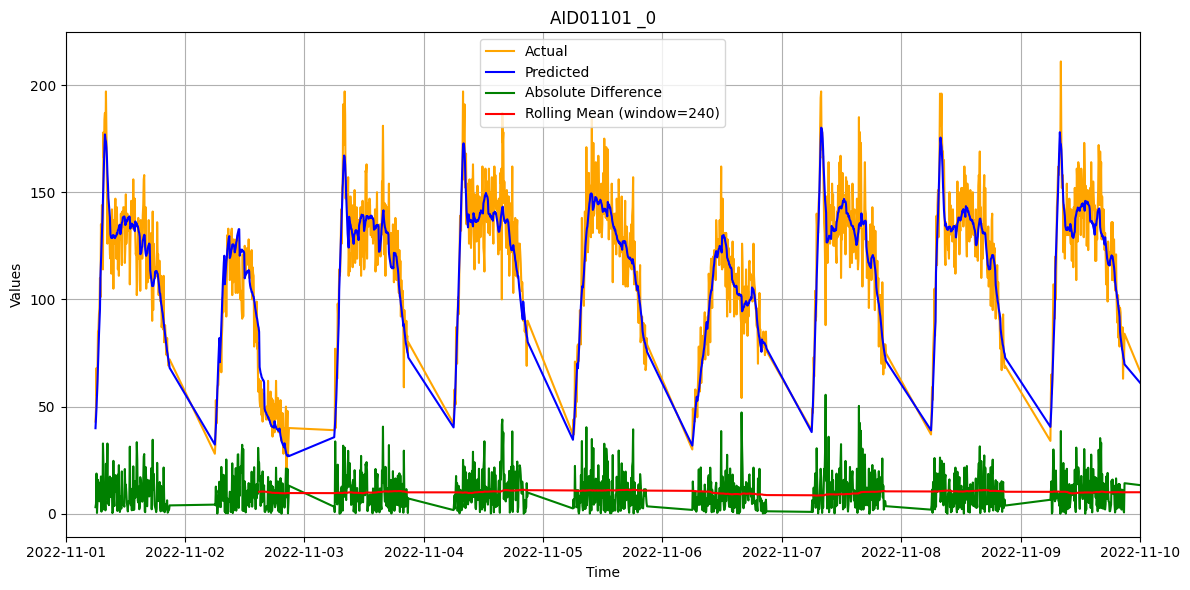

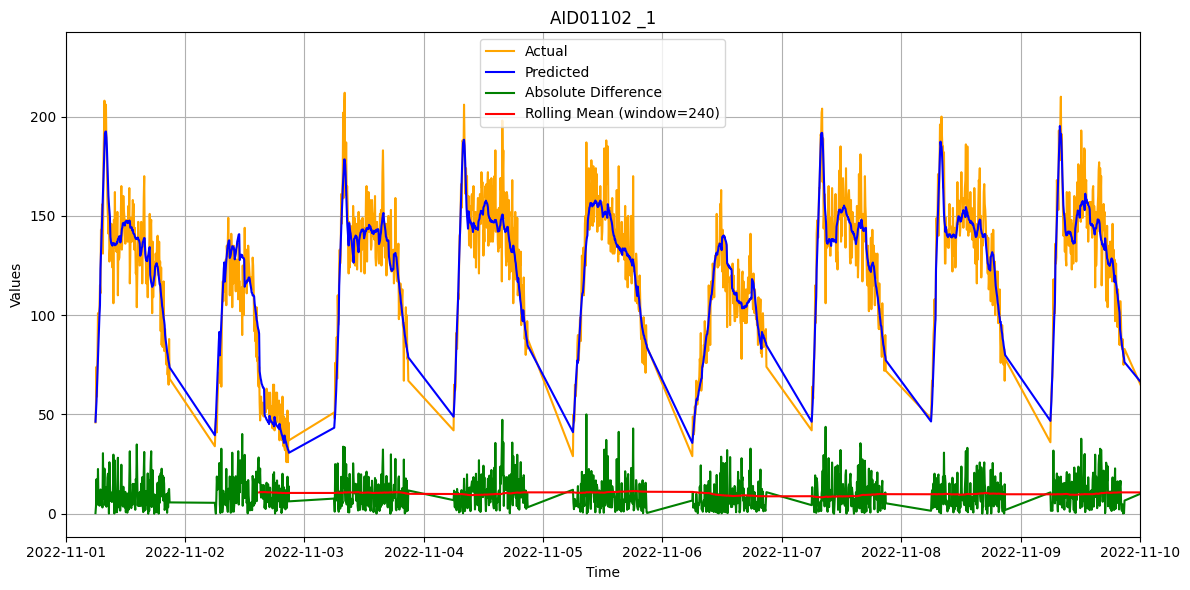

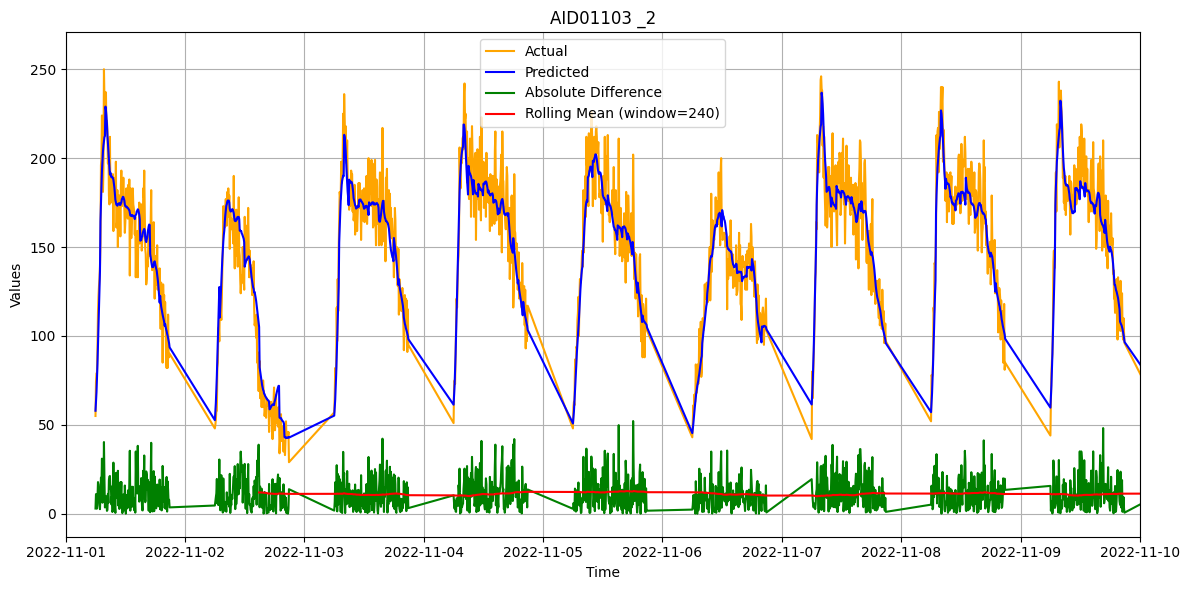

In [96]:
for i in range(3):
    actu = np.array(target_arr_all_clip[:, i])
    pred = np.array(pred_arr_all_clip[:, i])  # Extract data for each detector i
    detector_column = df.columns[i]  # Assuming column names follow this pattern
    plot_timeseries_dual(date_range, actu, pred, start_time='11/01/22', end_time='11/10/22', title=detector_column + ' _'+ str(i))

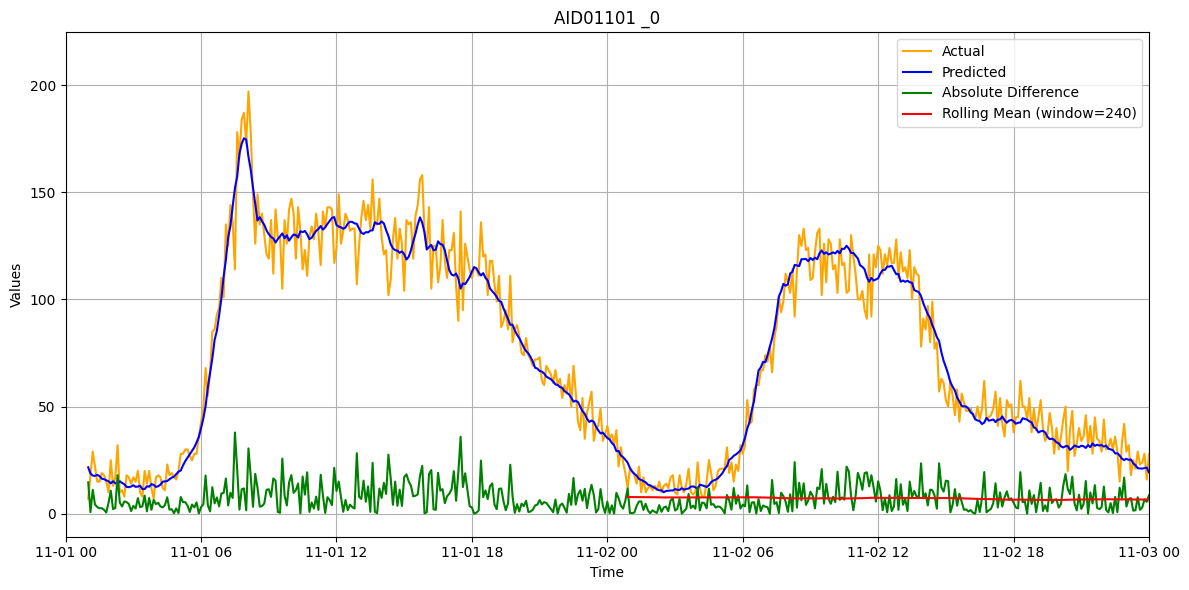

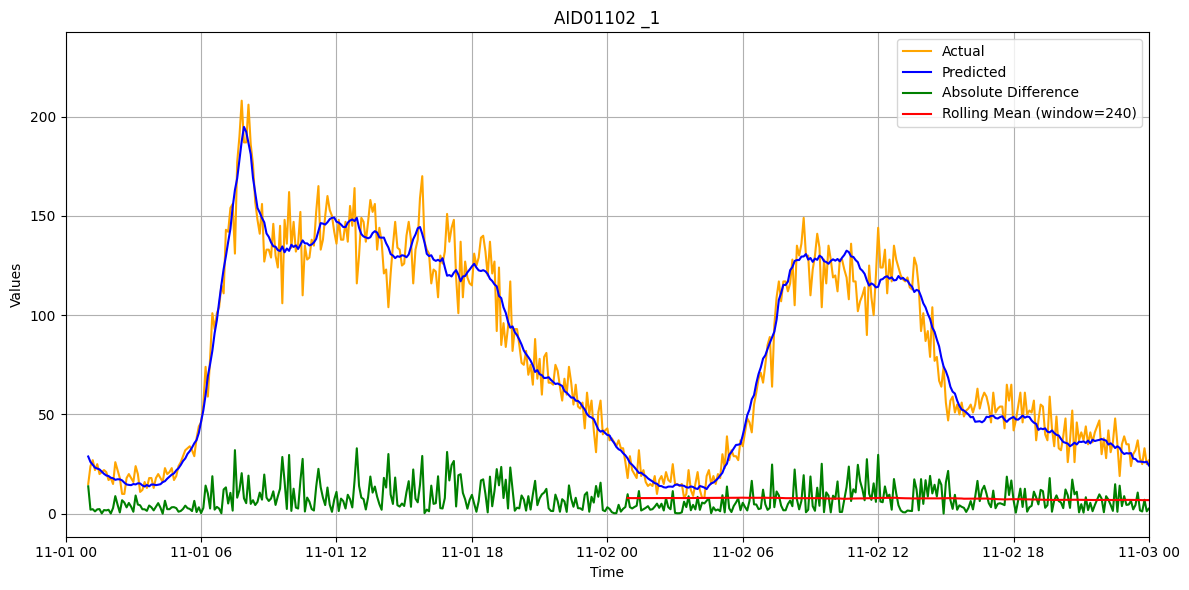

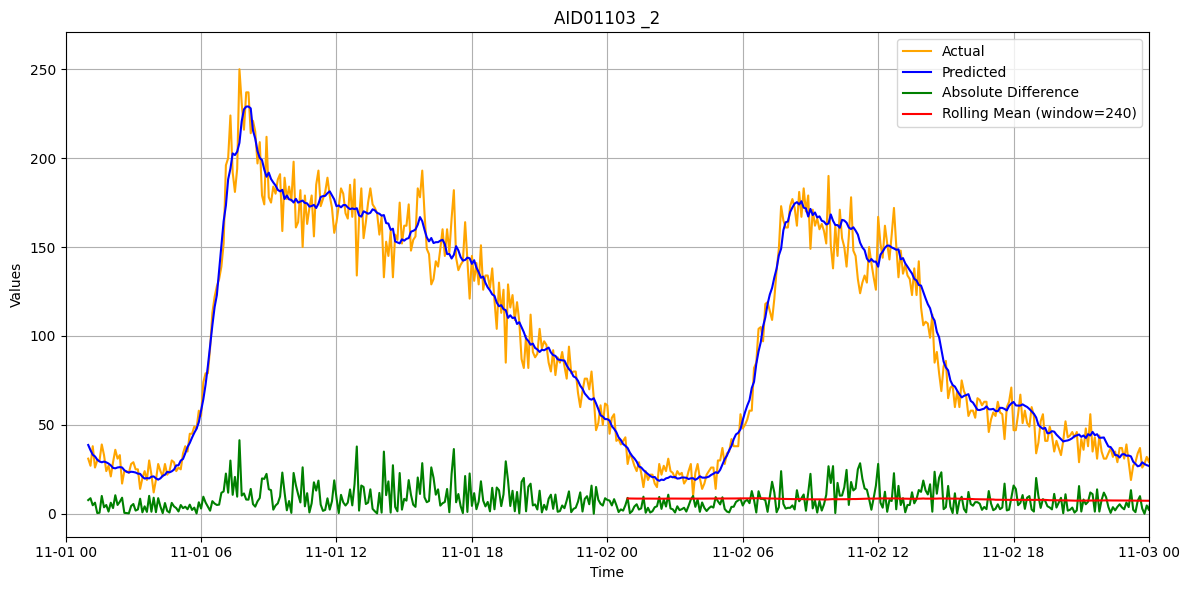

In [24]:
for i in range(3):
    arr = np.array(pred_arr[:, 0, i])  # Extract data for each detector i
    detector_column = df.columns[i]  # Assuming column names follow this pattern
    plot_timeseries_dual(df_val['timestamp'][10:-9], df_val[detector_column][10:-9], arr, start_time='11/01/22', end_time='11/3/22', title=detector_column + ' _'+ str(i))

In [98]:
diff_arr = abs(target_arr_all_clip-pred_arr_all_clip)
percent_arr = np.where(target_arr_all_clip != 0, 100 * np.abs(target_arr_all_clip - pred_arr_all_clip) / target_arr_all_clip, 100)
percent_arr = np.clip(percent_arr, 0, 100)
diff_arr.shape

C:\Users\Nahush\AppData\Local\Temp\ipykernel_10256\3918978684.py:2: RuntimeWarning: divide by zero encountered in divide
  percent_arr = np.where(target_arr_all_clip != 0, 100 * np.abs(target_arr_all_clip - pred_arr_all_clip) / target_arr_all_clip, 100)


(4500, 714)

In [103]:
percent_arr.shape

(4500, 714)

In [104]:
diff_df = pd.DataFrame(diff_arr, index=date_range, columns=detectors)
diff_df = diff_df.resample('1d').sum()

percent_df = pd.DataFrame(percent_arr, index=date_range, columns=detectors)
percent_df = percent_df.resample('1d').mean()

In [77]:
diff_1 = diff_arr[:,0,:]
diff_1.shape

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [76]:
start_time = pd.Timestamp('2022-11-01 01:00:00')  # Replace with your actual start time
end_time = pd.Timestamp('2022-11-30 23:00:00')      # Replace with your actual end time
# Step 1: Prepare Timestamps
timestamps = pd.date_range(start=start_time, end=end_time, freq='6T')
len(timestamps)
diff_1_df = pd.DataFrame(diff_1, index=timestamps, columns=detectors)

C:\Users\Nahush\AppData\Local\Temp\ipykernel_10256\3746138595.py:4: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start=start_time, end=end_time, freq='6T')


NameError: name 'diff_1' is not defined

In [ ]:
diff_1_df = diff_1_df.resample('1d').sum()
diff_1_df

In [78]:
df_triplets = pd.read_csv('triplets.csv')
df_duets = pd.read_csv('duets.csv')
print(df_triplets.to_string())

                  0               1               2
0          AID01101        AID01102        AID01103
1          AID01102        AID01103        AID01104
2          AID01103        AID01104        AID01105
3          AID01104        AID01105        AID01106
4          AID01105        AID01106        AID01107
5          AID01108        AID01109        AID01110
6          AID01111        AID01112        AID01113
7          AID01112        AID01113        AID01114
8          AID01113        AID01114        AID01115
9          AID01114        AID01115        AID01116
10         AID01115        AID01116        AID01117
11         AID01116        AID01117        AID01118
12         AID01117        AID01118        AID01119
13         AID01118        AID01119        AID01120
14         AID01119        AID01120        AID01121
15         AID01120        AID01121        AID01122
16         AID01121        AID01122        AID01123
17         AID01124        AID01125        AID01126
18         A

In [79]:
df_val.loc[:,'timestamp'] = pd.to_datetime(df_val['timestamp'], errors='coerce')
df_val.set_index("timestamp",inplace=True)
df_6min = df_val.resample('1d').sum()
df_6min

,AID01101,AID01102,AID01103,AID01104,AID01105,AID01106,AID01107,AID01108,AID01109,AID01110,...,TDSTYR10002,TDSTYR10003,TDSTYR20001,TDSTYR20003,TDSYSR10001,TDSYSR10002,TDSYSR10003,TDSYSR20001,TDSYSR20002,TDSYSR20003
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-11-01,21024.000000,22601.000000,27714.000000,18308.000000,20203.000000,22375.000000,21848.000000,18064.000000,34776.000000,50284.000000,...,2554.0,1283.0,4898.0,2965.0,18872.0,17752.0,10708.0,17791.000000,14917.0,10250.0
2022-11-02,13766.000000,14929.000000,18169.000000,11797.000000,13092.000000,14372.000000,14029.000000,13512.000000,24704.000000,31797.000000,...,1798.0,766.0,3513.0,2081.0,12969.0,17819.5,7400.0,12096.000000,13423.5,6992.0
2022-11-03,21213.000000,22755.000000,28057.000000,18552.000000,20337.000000,22364.000000,21931.000000,18731.000000,36208.000000,50894.000000,...,2526.0,1143.0,4898.0,3079.0,17822.0,18008.5,10488.0,17946.000000,14958.5,9890.0
2022-11-04,22965.000000,24723.000000,30218.000000,20175.000000,22092.000000,22942.000000,22232.000000,19874.000000,38805.000000,53578.000000,...,2626.0,1161.0,4925.0,3115.0,19916.0,18316.0,10922.0,19113.000000,15783.0,10995.0
2022-11-05,21909.000000,23734.000000,29288.000000,20312.000000,21857.000000,22986.000000,22471.000000,19305.000000,37588.000000,52209.000000,...,2862.0,1468.0,5249.0,3328.0,20003.0,16807.5,12014.0,18578.000000,14303.5,11273.0
2022-11-06,17972.000000,19442.000000,24511.000000,17490.000000,18584.000000,20586.000000,20042.000000,18101.000000,33793.000000,45650.000000,...,2459.0,1277.0,4386.0,2705.0,16164.0,13505.0,10501.0,14943.000000,11833.0,9901.0
2022-11-07,21641.886708,23359.879756,28855.221352,19299.305591,20915.547934,22714.969623,22231.199372,18955.970487,35872.442001,51840.918367,...,2570.0,1189.0,4801.0,3023.0,19375.0,17576.5,11320.0,18107.956656,14994.0,10819.0
2022-11-08,21846.000000,23604.000000,29259.000000,19379.000000,21235.000000,22652.000000,22112.000000,19295.000000,36882.000000,52347.000000,...,2543.0,1166.0,5039.0,3066.0,19418.0,17752.0,11366.0,18682.000000,15246.0,11008.0
2022-11-09,22343.000000,23936.000000,29668.000000,19684.000000,21293.000000,22330.000000,22652.000000,18661.000000,35790.000000,53195.000000,...,2632.0,1279.0,4938.0,3095.0,20202.0,17819.5,11838.0,19069.000000,15358.5,11346.0


In [119]:
# df.loc[:,'timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
# df.set_index("timestamp",inplace=True)

df_new = df_6min.copy()
df_new[:] = np.nan
for idx in df_6min.index:
    for i in df_6min.columns:

        if(df_6min.loc[idx,i]==np.nan):
            df_new.loc[idx,i]=np.nan
            continue

        corr = np.nan
        row_id_0 = df_triplets.index[df_triplets['0'].isin([i])]
        row_id_1 = df_triplets.index[df_triplets['1'].isin([i])]
        row_id_2 = df_triplets.index[df_triplets['2'].isin([i])]
        if(not(row_id_1.empty)):
            det = df_triplets.loc[row_id_1].values.flatten().tolist()
            t1 = det[0] in df.columns
            t3 = det[2] in df.columns

            if(t1 and t3):
                det1 = df.loc[idx: idx + pd.DateOffset(days=1),det[0]]
                det2 = df.loc[idx: idx + pd.DateOffset(days=1),det[1]]
                det3 = df.loc[idx: idx + pd.DateOffset(days=1),det[2]]

                corr = (det2.corr(det1) + det2.corr(det3))/2
            elif(t1 and not(t3)):
                det1 = df.loc[idx: idx + pd.DateOffset(days=1),det[0]]
                det2 = df.loc[idx: idx + pd.DateOffset(days=1),det[1]]

                corr = det2.corr(det1)
            elif(t3 and not(t1)):
                det2 = df.loc[idx: idx + pd.DateOffset(days=1),det[1]]
                det3 = df.loc[idx: idx + pd.DateOffset(days=1),det[2]]

                corr = det2.corr(det3)                    

        elif(not(row_id_0.empty)):
            det = df_triplets.loc[row_id_0].values.flatten().tolist()
            t2 = det[1] in df.columns
            t3 = det[2] in df.columns

            det1 = df.loc[idx: idx + pd.DateOffset(days=1),det[0]]

            if(t2): 
                det2 = df.loc[idx: idx + pd.DateOffset(days=1),det[1]]
                corr = det1.corr(det2)

            elif(t3):
                det3 = df.loc[idx: idx + pd.DateOffset(days=1),det[2]]
                corr = det1.corr(det3)

            

        elif(not(row_id_2.empty)):
            det = df_triplets.loc[row_id_2].values.flatten().tolist()
            t1 = det[0] in df.columns
            t2 = det[1] in df.columns           
            det3 = df.loc[idx: idx + pd.DateOffset(days=1),det[2]]
                      
            if(t2):
                det2 = df.loc[idx: idx + pd.DateOffset(days=1),det[1]]
                corr = det2.corr(det3)
            elif(t1):
                det1 = df.loc[idx: idx + pd.DateOffset(days=1),det[0]]
                corr = det1.corr(det3)

            

        df_new.loc[idx,i] = corr

c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Program Files\Python311\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [120]:
# df_new.to_csv('data_matrix_new_xie.csv')
df_new = pd.read_csv('data_matrix_new_xie.csv')
df_new.loc[:,'timestamp'] = pd.to_datetime(df_new['timestamp'], errors='coerce')
df_new.set_index("timestamp",inplace=True)
print(df_new.to_string())

            AID01101  AID01102  AID01103  AID01104  AID01105  AID01106  AID01107  AID01108  AID01109  AID01110  AID01111  AID01112  AID01113  AID01114  AID01115  AID01116  AID01117  AID01118  AID01121  AID01122  AID01123  AID01124  AID01125  AID01126  AID01127  AID01128  AID01129  AID01131  AID01132  AID01133  AID01134  AID01135  AID01136  AID01201  AID01202  AID01203  AID01204  AID01206  AID01207  AID01208  AID01209  AID01210  AID01211  AID01212  AID01213  AID01214  AID01215  AID01216  AID01217  AID01218  AID01219  AID01220  AID01221  AID01222  AID01223  AID02104  AID02105  AID02106  AID02107  AID02108  AID02109  AID02110  AID02111  AID02112  AID02113  AID02114  AID02115  AID02116  AID02117  AID02118  AID02119  AID02120  AID02121  AID02122  AID02123  AID02124  AID02125  AID02126  AID02127  AID02201  AID02202  AID02203  AID02204  AID02205  AID02206  AID02207  AID02208  AID02209  AID02210  AID02211  AID02212  AID02213  AID02214  AID02215  AID03101  AID03102  AID03103  AID03104  AID03106

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


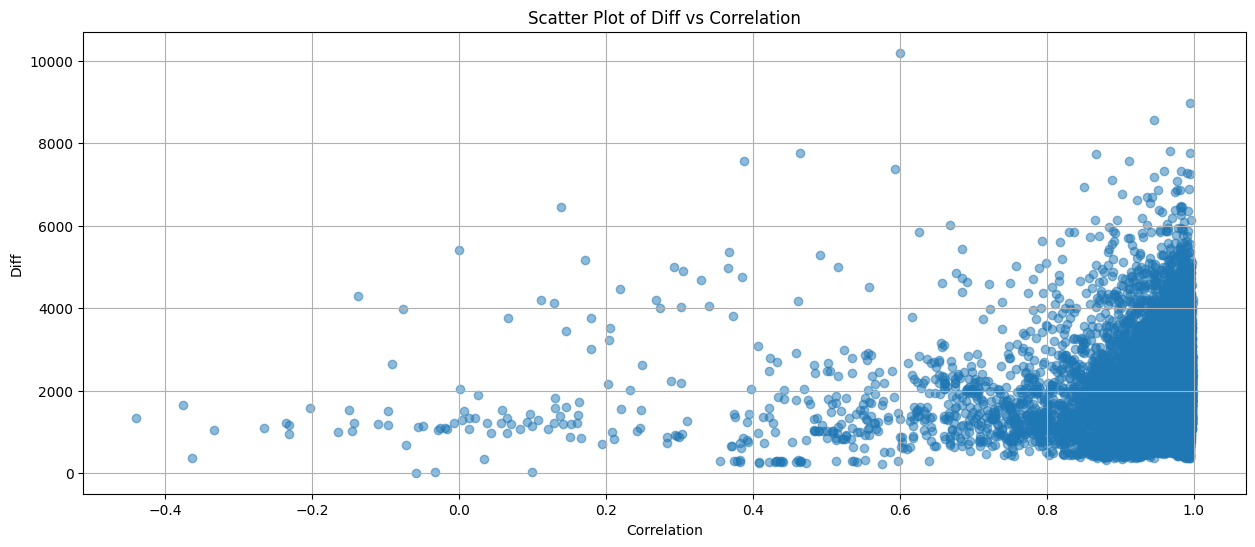

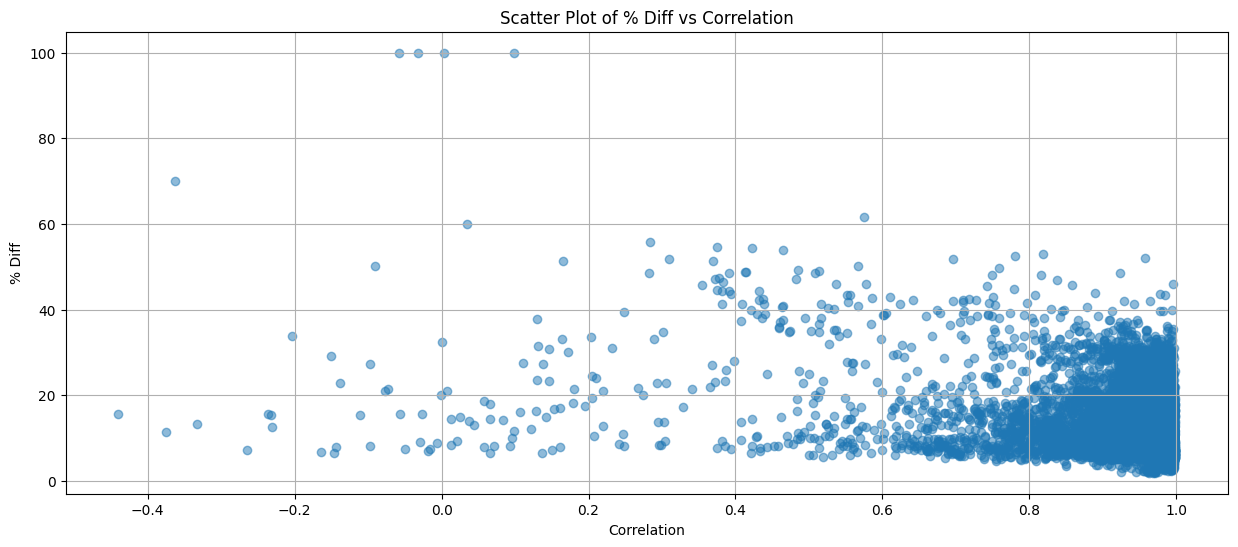

In [129]:
corr_flat = df_new.values.flatten()
diff_flat = diff_df.values.flatten()
percent_flat = percent_df.values.flatten()

# Create scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(corr_flat, diff_flat, alpha=0.5)
plt.xlabel('Correlation')
plt.ylabel('Diff')
plt.title('Scatter Plot of Diff vs Correlation')
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.scatter(corr_flat, percent_flat, alpha=0.5)
plt.xlabel('Correlation')
plt.ylabel('% Diff')
plt.title('Scatter Plot of % Diff vs Correlation')
plt.grid(True)
plt.show()

[39 39 38 ... 38 37 37]


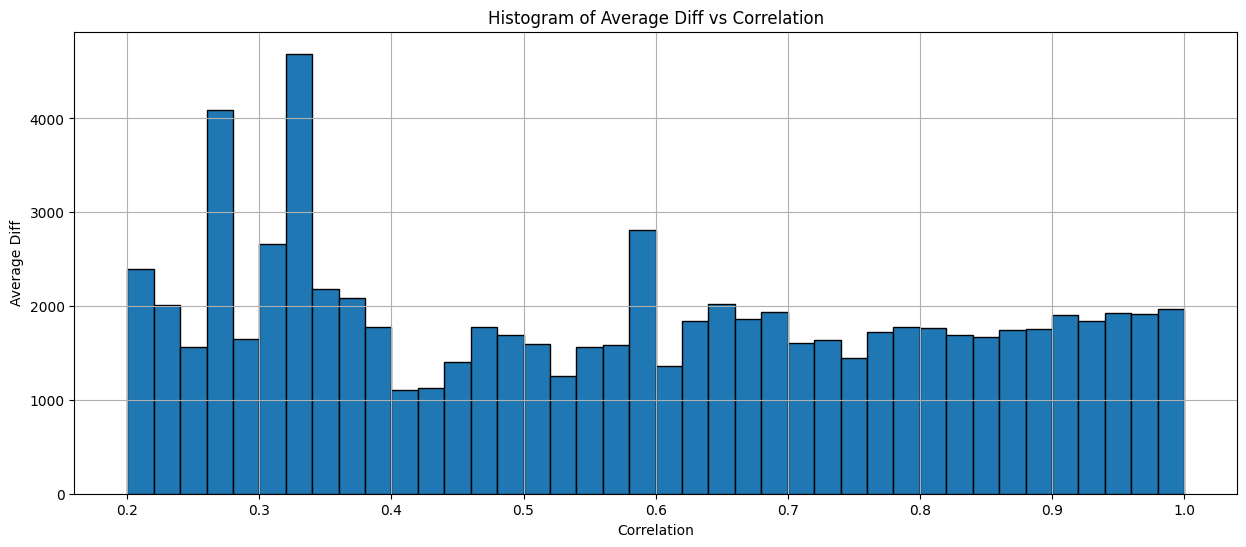

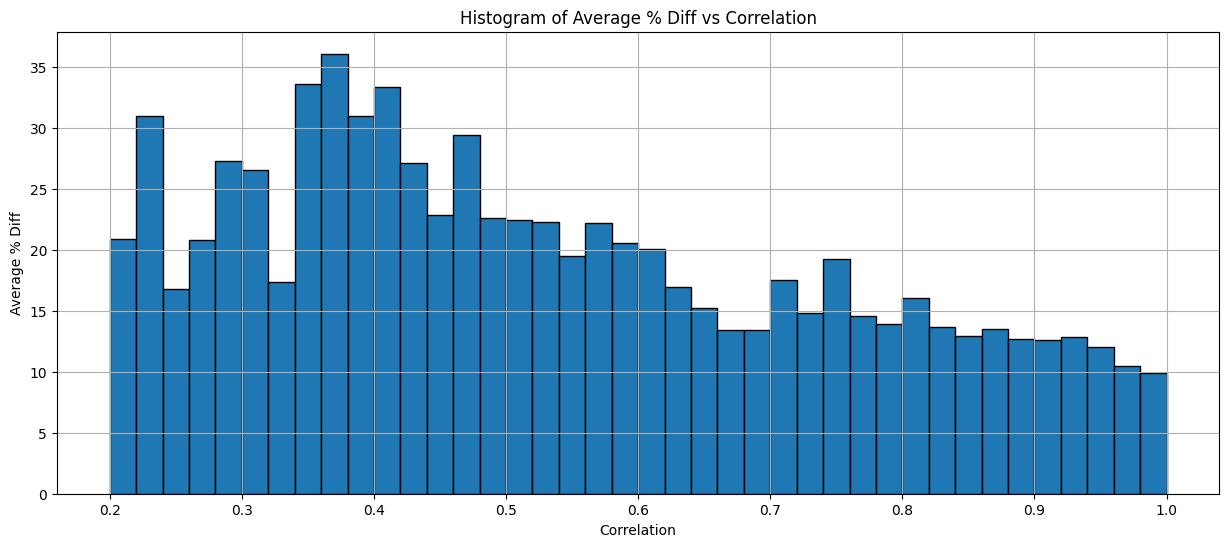

In [125]:
num_bins = 40

# Compute the bin edges and digitize the correlation data
bin_edges = np.linspace(0.2, 1, num_bins + 1)
bin_indices = np.digitize(corr_flat, bin_edges) - 1
print(bin_indices)
# Initialize an array to store the average rank for each bin
average_diff_per_bin = np.zeros(num_bins)
average_percent_per_bin = np.zeros(num_bins)

# Compute the average rank for each bin
for i in range(num_bins):
    average_diff_per_bin[i] = np.mean(diff_flat[bin_indices == i])
    average_percent_per_bin[i] = np.mean(percent_flat[bin_indices == i])

# Plot the histogram
plt.figure(figsize=(15, 6))
plt.bar(bin_edges[:-1], average_diff_per_bin, width=np.diff(bin_edges), align='edge', edgecolor='k')
plt.xlabel('Correlation')
plt.ylabel('Average Diff')
plt.title('Histogram of Average Diff vs Correlation')
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.bar(bin_edges[:-1], average_percent_per_bin, width=np.diff(bin_edges), align='edge', edgecolor='k')
plt.xlabel('Correlation')
plt.ylabel('Average % Diff')
plt.title('Histogram of Average % Diff vs Correlation')
plt.grid(True)
plt.show()

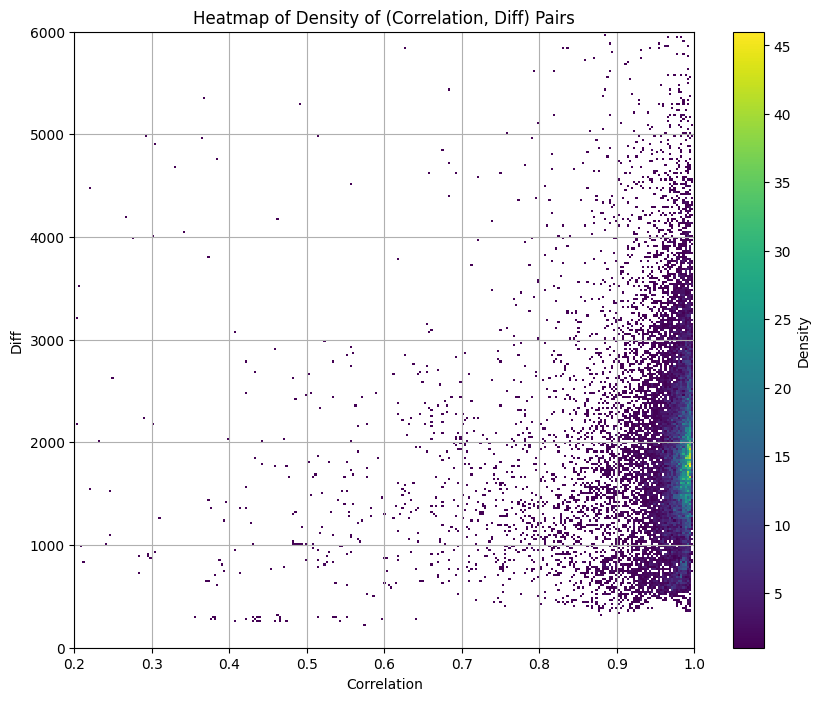

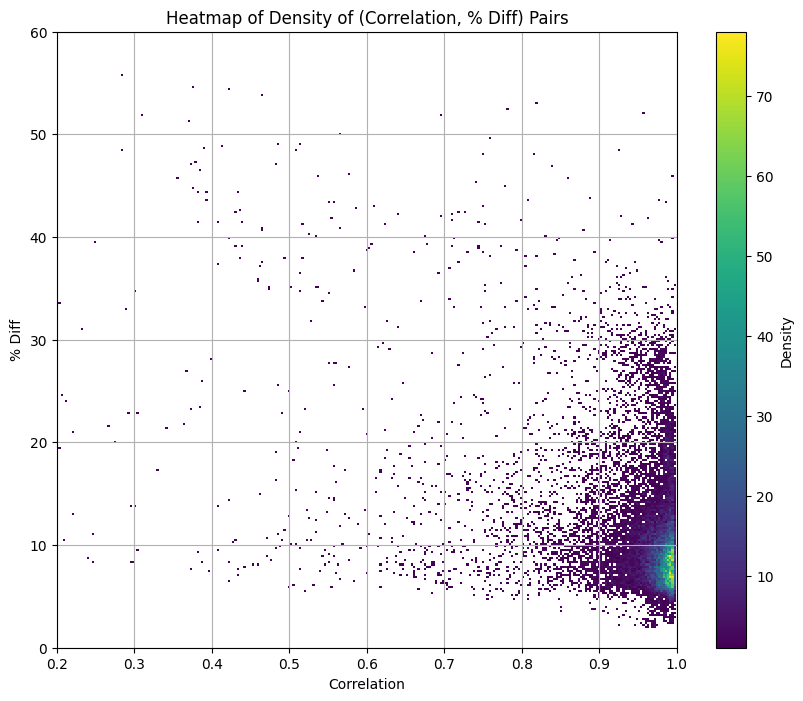

In [127]:
mask = ~np.isnan(corr_flat) & ~np.isnan(diff_flat)
corr_filtered = corr_flat[mask]
diff_filtered = diff_flat[mask]
percent_filtered = percent_flat[mask]
plt.figure(figsize=(10, 8))
plt.hist2d(corr_filtered, diff_filtered, bins=500, cmap='viridis', cmin=1)
plt.colorbar(label='Density')
plt.xlabel('Correlation')
plt.ylabel('Diff')
plt.xlim(0.2,1)
plt.ylim(0,6000)
plt.title('Heatmap of Density of (Correlation, Diff) Pairs')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 8))
plt.hist2d(corr_filtered, percent_filtered, bins=500, cmap='viridis', cmin=1)
plt.colorbar(label='Density')
plt.xlabel('Correlation')
plt.ylabel('% Diff')
plt.xlim(0.2,1)
plt.ylim(0,60)
plt.title('Heatmap of Density of (Correlation, % Diff) Pairs')
plt.grid(True)
plt.show()

In [ ]:
for i in range(10):
    col = diff_1_df.columns[i]
    plt.figure(figsize=(14, 10))  # Adjust size as needed
    plt.plot(diff_1_df.index, diff_1_df[col], label=col)
    plt.xlabel('Time')
    plt.ylabel(col)
    plt.title(f'Time Series Plot for {col}')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def getMetrics(predictions, targets, maskVols):
    predictions_np = predictions.cpu().numpy()
    targets_np = targets.cpu().numpy()
    
    # Filter out zero values from targets to avoid division by zero in MAPE calculation
    non_zero_targets = targets_np != 0
    filtered_predictions = predictions_np[non_zero_targets]
    filtered_targets = targets_np[non_zero_targets]
    
    mae = np.mean(np.abs(filtered_predictions - filtered_targets))
    rmse = np.sqrt(np.mean((filtered_predictions - filtered_targets) ** 2))
    mape = np.mean(np.abs((filtered_predictions - filtered_targets) / filtered_targets)) * 100
    
    return mae, rmse, mape

In [ ]:
if volSpeed == 'vol':
    maskVols = [10] 
elif volSpeed == 'Speed':
    maskVols = [1]    
PredTarget = torch.FloatTensor(PredTarget)
for tsi in range(PredTarget.shape[1]):
    pred_friA_ti = RePredAll_fri[:,tsi]
    realRaw_tsi = PredTarget[:,tsi]
    outPred_tsi,tarReal_tsi = pred_friA_ti.reshape(-1),realRaw_tsi.reshape(-1)
    checkNan = outPred_tsi+tarReal_tsi
    outPred_tsi = outPred_tsi[~torch.isnan(checkNan)]
    tarReal_tsi = tarReal_tsi[~torch.isnan(checkNan)]
    mae1,rmse1,mapes1 = getMetrics(outPred_tsi,tarReal_tsi,maskVols)
    mae1,rmse1,mapes1 = np.array(mae1),np.array(rmse1),np.array(mapes1)
    print('{:.0f}:\t{:.2f};\t{:.2f};\t{:.2f};'.format(tsi,mae1,rmse1,mapes1))
# printT()